In [76]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
# Leitura do arquivo

arquivo = 'tratados_10x10det/carbon/carbon1E14_array'

df = pl.read_csv(arquivo, has_header= False).filter(pl.col('column_1').str.contains('TRIG'))

df = df.with_columns(pl.col("column_1").str.split(" ").alias("split_column"))
df = df.with_columns(pl.col("split_column").list.get(0).alias("TRIG"))
df = df.with_columns(pl.col("split_column").list.get(1).cast(pl.Int64).alias("positrons"))
df = df.with_columns(pl.col("split_column").list.get(2).cast(pl.Int64).alias("electrons"))
df = df.with_columns(pl.col("split_column").list.get(3).cast(pl.Int64).alias("muons_plus"))
df = df.with_columns(pl.col("split_column").list.get(4).cast(pl.Int64).alias("muons_minus"))
df = df.with_columns(
    (pl.col("positrons") + pl.col("electrons") + pl.col("muons_plus") + pl.col("muons_minus")).alias("total_particles")
)

df

column_1,split_column,TRIG,positrons,electrons,muons_plus,muons_minus,total_particles
str,list[str],str,i64,i64,i64,i64,i64
"""TRIG1 0 0 0 0""","[""TRIG1"", ""0"", … ""0""]","""TRIG1""",0,0,0,0,0
"""TRIG2 1 0 0 0""","[""TRIG2"", ""1"", … ""0""]","""TRIG2""",1,0,0,0,1
"""TRIG3 0 0 0 0""","[""TRIG3"", ""0"", … ""0""]","""TRIG3""",0,0,0,0,0
"""TRIG4 0 0 0 0""","[""TRIG4"", ""0"", … ""0""]","""TRIG4""",0,0,0,0,0
"""TRIG5 0 0 0 0""","[""TRIG5"", ""0"", … ""0""]","""TRIG5""",0,0,0,0,0
…,…,…,…,…,…,…,…
"""TRIG96 0 0 0 0""","[""TRIG96"", ""0"", … ""0""]","""TRIG96""",0,0,0,0,0
"""TRIG97 0 0 0 0""","[""TRIG97"", ""0"", … ""0""]","""TRIG97""",0,0,0,0,0
"""TRIG98 0 0 0 0""","[""TRIG98"", ""0"", … ""0""]","""TRIG98""",0,0,0,0,0


In [78]:
import re
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(arquivo)
name

'Carbon 1E14'

In [79]:
# Transformação das contagens de partículas em listas e na média de contagens

df2 = df.group_by('TRIG').agg(pl.col('total_particles')).sort(
    pl.col('TRIG').str.extract(r"TRIG([0-9]*)", 1).cast(int)
)
#df2 = df2.with_columns(mean_particles = pl.col('total_particles').list.mean())  
#df2

In [81]:
# Posição dos tanques

numDetectors = 100
gridSize = 10
spacing = 10
area = 1.0

x_det = np.zeros(numDetectors)
y_det = np.zeros(numDetectors)
areas = np.full(numDetectors, area)

index = 0
halfGridSize = gridSize // 2

for i in range(gridSize):
    for j in range(gridSize):
        x_det[index] = (j - halfGridSize + 0.5) * spacing
        y_det[index] = (i - halfGridSize + 0.5) * spacing
        areas[index] = area
        index += 1

print("x_det:", x_det)
print("y_det:", y_det)
print("areas:", areas)


x_det: [-45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.
  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.
  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35.
 -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.
  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45.
 -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.
  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.
  35.  45.]
y_det: [-45. -45. -45. -45. -45. -45. -45. -45. -45. -45. -35. -35. -35. -35.
 -35. -35. -35. -35. -35. -35. -25. -25. -25. -25. -25. -25. -25. -25.
 -25. -25. -15. -15. -15. -15. -15. -15. -15. -15. -15. -15.  -5.  -5.
  -5.  -5.  -5.  -5.  -5.  -5.  -5.  -5.   5.   5.   5.   5.   5.   5.
   5.   5.   5.   5.  15.  15.  15.  15.  15.  15.  15.  15.  15.  15.
  25.  25.  25.  25.  25.  25.  25.  25.  25.  25.  35.  35.  35.  35.
  35.  35.  35.  35.  35.  35.  45.  45.  45.  45. 

In [ ]:
from scipy.spatial import KDTree

# Método KDTree 
positions = np.column_stack((x_det, y_det))
tree = KDTree(positions)
d_max = 15  # Distância máxima para considerar como próximos

# Validar simulações com triangulação
num_simulations = len(df2["total_particles"][0])

valid_simulations = []

for sim_idx in range(num_simulations):
    detections = np.array([df2["total_particles"][i][sim_idx] > 0 for i in range(100)])  

    detected_indices = np.where(detections)[0]
    if len(detected_indices) < 3:
        continue
    
    neighbors = []
    for tank in detected_indices:
        neighbors.append(set(tree.query_ball_point(positions[tank], d_max)))
    
    valid = False
    n = len(detected_indices)
    for i in range(n):
        tank_i = detected_indices[i]
        for j in range(i + 1, n):
            tank_j = detected_indices[j]
            if tank_j not in neighbors[i]:  
                continue
            for k in range(j + 1, n):
                tank_k = detected_indices[k]
                if tank_k in neighbors[i] and tank_k in neighbors[j]:
                    valid = True
                    break
            if valid:
                break
        if valid:
            break
    
    if valid:
        valid_simulations.append(sim_idx)


# Atualizar o dataframe
triangulation_particles = [
    [particles[i] for i in valid_simulations] for particles in df2["total_particles"]
]

triangulation_particles = df2.with_columns(
    pl.Series("triangulation_particles", triangulation_particles)
)

print(f"Simulações válidas: {len(valid_simulations)}")
triangulation_particles

Simulações válidas: 106


TRIG,total_particles,triangulation_particles
str,list[i64],list[i64]
"""TRIG1""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG2""","[1, 0, … 0]","[1, 0, … 1]"
"""TRIG3""","[0, 0, … 0]","[0, 0, … 1]"
"""TRIG4""","[0, 0, … 0]","[0, 0, … 1]"
"""TRIG5""","[0, 0, … 0]","[0, 0, … 0]"
…,…,…
"""TRIG96""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG97""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG98""","[0, 0, … 0]","[0, 0, … 0]"


In [84]:
triangulation_particles = triangulation_particles.with_columns(mean_particles = pl.col('triangulation_particles').list.mean())  
trigs = triangulation_particles['mean_particles'].to_list()
triangulation_particles

TRIG,total_particles,triangulation_particles,mean_particles
str,list[i64],list[i64],f64
"""TRIG1""","[0, 0, … 0]","[0, 0, … 0]",0.018868
"""TRIG2""","[1, 0, … 0]","[1, 0, … 1]",0.037736
"""TRIG3""","[0, 0, … 0]","[0, 0, … 1]",0.122642
"""TRIG4""","[0, 0, … 0]","[0, 0, … 1]",0.09434
"""TRIG5""","[0, 0, … 0]","[0, 0, … 0]",0.028302
…,…,…,…
"""TRIG96""","[0, 0, … 0]","[0, 0, … 0]",0.103774
"""TRIG97""","[0, 0, … 0]","[0, 0, … 0]",0.04717
"""TRIG98""","[0, 0, … 0]","[0, 0, … 0]",0.037736


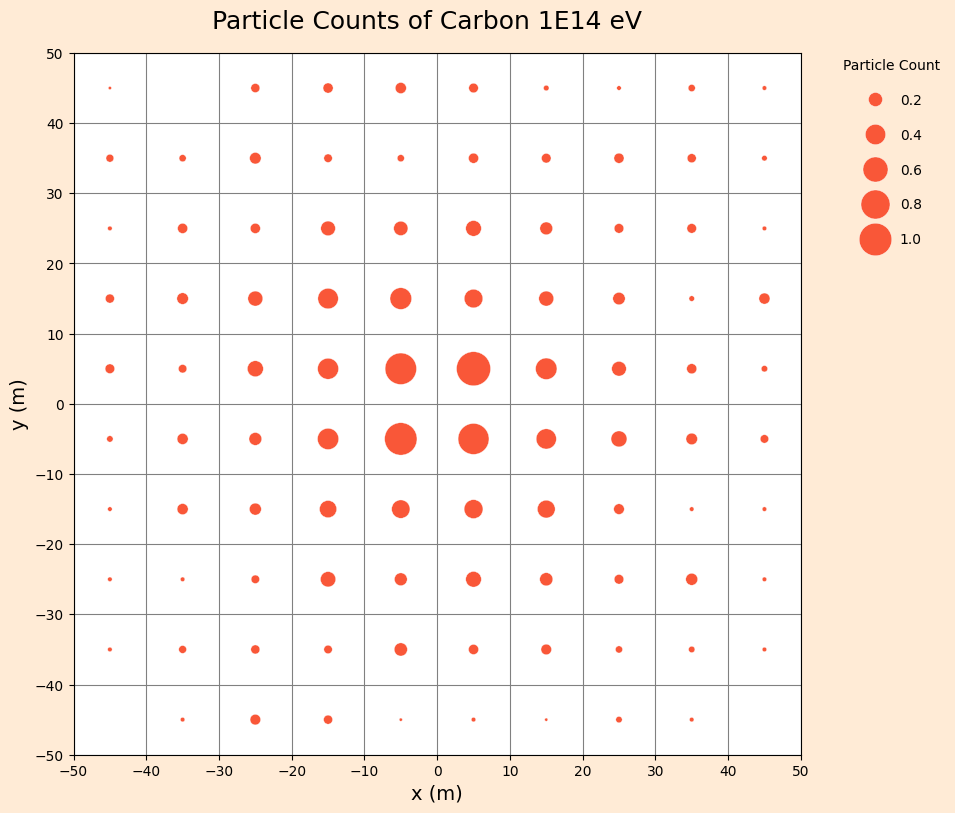

In [85]:
# Plot de partículas por tanque
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Particle Counts of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

scatter = sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', size=trigs, sizes=(0, 600), legend = 'brief')
handles, labels = scatter.get_legend_handles_labels()
for handle in handles:
    handle.set_color('#F95738')
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
           frameon=False, title='Particle Count', labelspacing = 1.5)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


plt.savefig('plots/counts_' + arquivo.split('/')[-1].split('_')[0] + '.png', bbox_inches = 'tight', dpi = 300)

In [86]:
# O primeiro índice é o trig do tanque, e o segundo é o evento. Apenas um exemplo
#df2['count'][0][0]*x_det[0]+df2['count'][1][0]*x_det[1]+ df2['count'][2][0]*x_det[2]/(df2['count'][0][0]+df2['count'][1][0]+df2['count'][2][0])

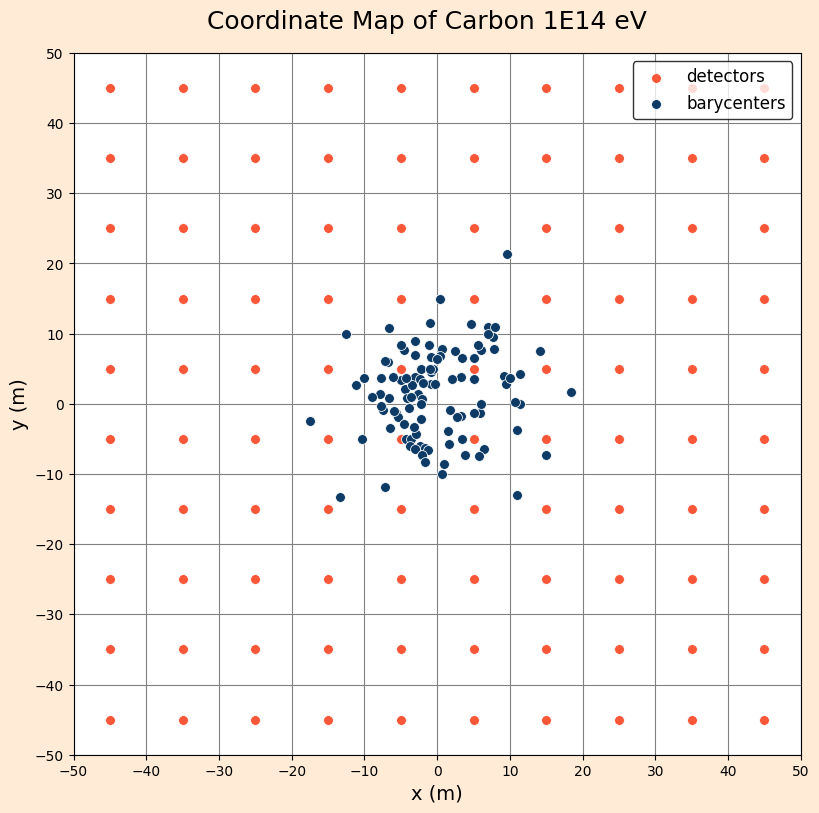

In [87]:
# Posição dos baricentros
x_b = [0] * len(valid_simulations)
y_b = [0] * len(valid_simulations)

for i in range(len(valid_simulations)):
        numerator = 0
        numerator1 = 0
        denominator = 0
        for j in range(len(trigs)):
                numerator += (triangulation_particles['triangulation_particles'][j][i]*x_det[j])
                numerator1 += (triangulation_particles['triangulation_particles'][j][i]*y_det[j])
                denominator += (triangulation_particles['triangulation_particles'][j][i])
                if denominator != 0: 
                    x_b[i] = numerator / denominator
                    y_b[i] = numerator1 / denominator
                else:
                    x_b[i] = 0 
                    y_b[i] = 0 

fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)
sns.scatterplot(x = x_b, y = y_b, ax = ax, color = '#0D3B66',s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

plt.savefig('plots/map_' + arquivo.split('/')[-1].split('_')[0] + '.png',bbox_inches = 'tight', dpi = 300)

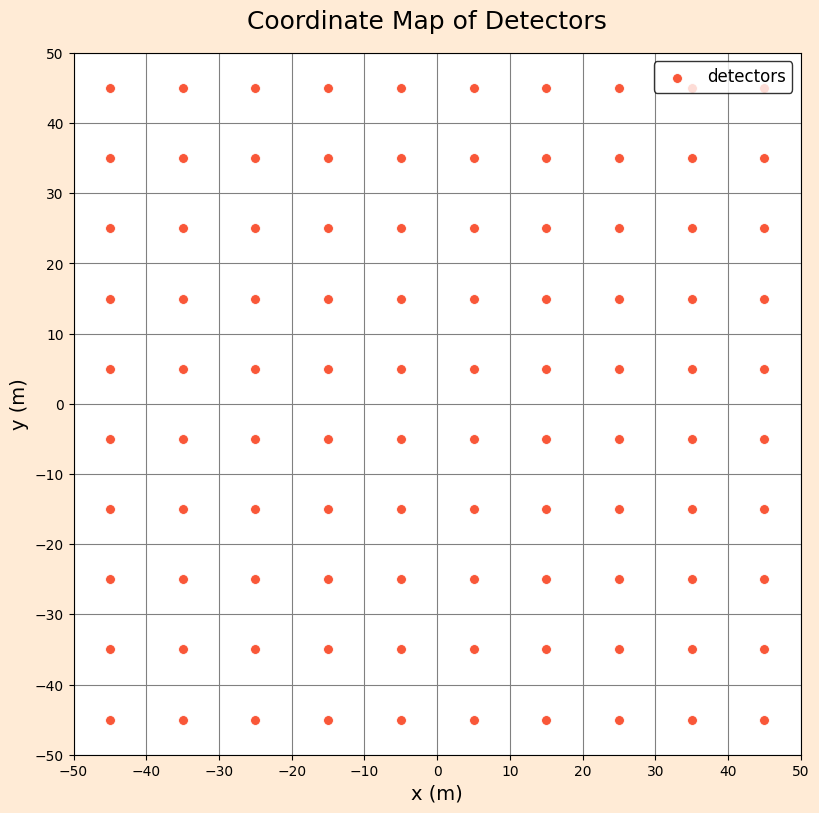

In [88]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of Detectors', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors'], edgecolor = 'black', fontsize = 12, loc = 1)

In [89]:
# Criação de arquivo de dados para construir a função de distribuição lateral

r_b = [] 
for i in range(len(valid_simulations)):
    #aux = ((x_det[i]-x_b[i])**2 + (y_det[i]-y_b[i])**2)**0.5
    aux = x_b[i]** 2 + y_b[i]**2
    r_b.append(aux)

data = {
    'x_b':x_b,
    'y_b':y_b,
    'r_b':r_b
}

df = pl.DataFrame(data, strict=False)


#df3 = triangulation_particles.with_columns(
#    pl.Series(name='x_b', values=[float(x) for x in x_b]),
#    pl.Series(name='y_b', values=[float(y) for y in y_b]),
#    pl.Series(name='r_b', values=[float(r) for r in r_b])
#).drop('triangulation_particles', 'total_particles', strict=False)

#df3.write_csv('bary_dat/' + arquivo.split('/')[-1] + '_fdl.csv', separator= '\t', include_header= False)

In [90]:
df

x_b,y_b,r_b
f64,f64,f64
6.428571,-6.428571,82.653061
-5.625,-1.25,33.203125
-6.666667,0.833333,45.138889
7.727273,9.545455,150.826446
-1.666667,-8.333333,72.222222
…,…,…
9.545455,21.363636,547.520661
4.6,11.4,151.12
-5.0,8.333333,94.444444


[1.03619068e-15 1.38609350e-02]
[4.41496002 5.09542909 5.77675041]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_36376\3515581692.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_36376\3515581692.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.418964,14.0,14.00294,0.021001
5.087426,14.499687,14.493811,0.040529
5.780749,15.0,15.002936,0.019576


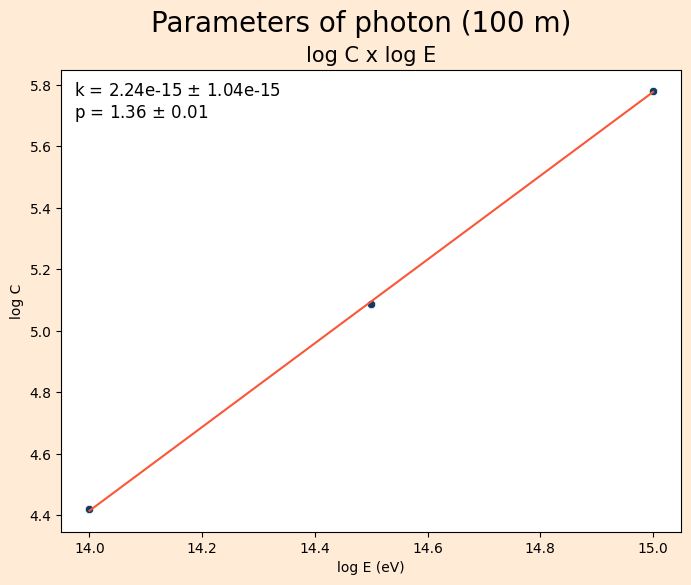

In [91]:
# Fit do fóton
from scipy.optimize import curve_fit

C = [2.624E4, 1.223E5, 6.036E5]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_photon))

ax.plot(logE, power(E,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_photon[0]))/coefficients_photon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[1.35649802e-13 3.84310014e-03]
[4.62103782 5.21341874 5.8065416 ]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_36376\184948920.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_36376\184948920.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.619928,14.0,13.999064,0.006689
5.215638,14.499687,14.501559,0.012908
5.805433,15.0,14.999065,0.006235


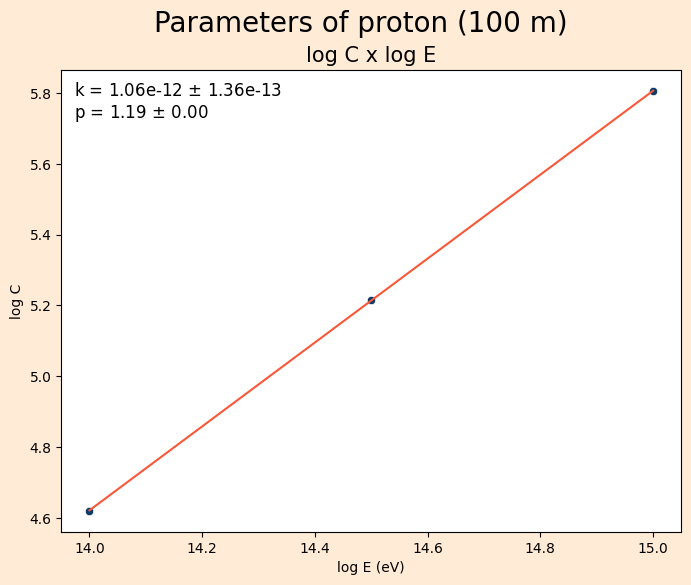

In [92]:
# Fit do próton
from scipy.optimize import curve_fit

C = [4.168e+04, 1.643e+05, 6.389e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_proton, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_proton))

ax.plot(logE, power(E,*coefficients_proton), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_proton[0],inc[0],coefficients_proton[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_proton[0]))/coefficients_proton[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[2.12202004e-06 2.38934361e-01]
[4.27281222 4.66000189 5.04767649]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_36376\3661086127.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_36376\3661086127.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.34183,14.0,14.089071,0.636221
4.522053,14.499687,14.321657,1.22782
5.116608,15.0,15.088959,0.593061


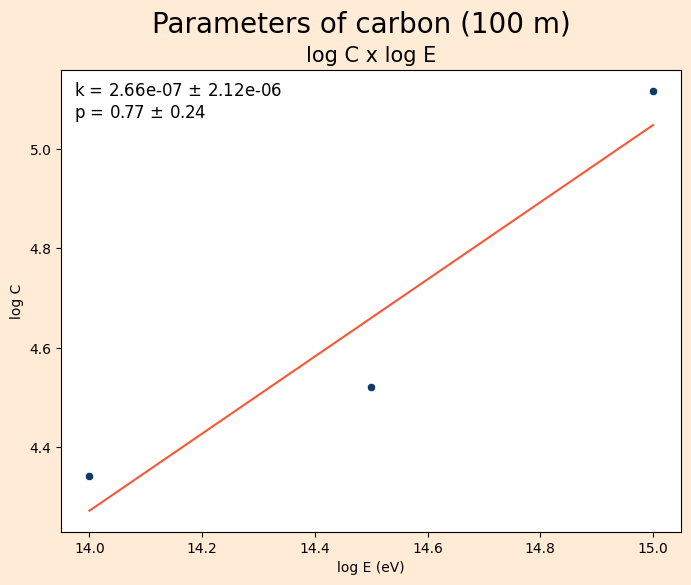

In [93]:
# Fit do carbono
from scipy.optimize import curve_fit

C = [2.197e+04, 3.327e+04, 1.308e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of carbon (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_carbon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_carbon))

ax.plot(logE, power(E,*coefficients_carbon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_carbon[0],inc[0],coefficients_carbon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_carbon[0]))/coefficients_carbon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[6.16995911e-16 8.87504152e-02]
[3.71289752 4.40512596 5.09822138]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_36376\3240931431.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_36376\3240931431.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.687261,14.0,13.981494,0.132182
4.456366,14.499687,14.536675,0.255094
5.072617,15.0,14.981518,0.123215


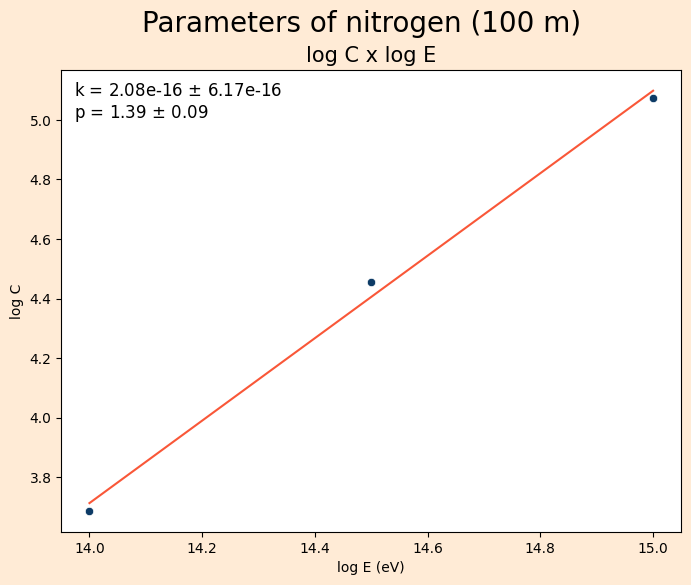

In [94]:
# Fit do nitrogênio
from scipy.optimize import curve_fit

C = [4867, 2.86e+04, 1.182e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of nitrogen (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_nitrogen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_nitrogen))

ax.plot(logE, power(E,*coefficients_nitrogen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_nitrogen[0],inc[0],coefficients_nitrogen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_nitrogen[0]))/coefficients_nitrogen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[3.30510011e-16 2.46194254e-02]
[3.7298276  4.41245988 5.09594713]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_36376\1506402242.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_36376\1506402242.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.722716,14.0,13.994794,0.037183
4.426674,14.499687,14.510092,0.071758
5.088845,15.0,14.994801,0.034661


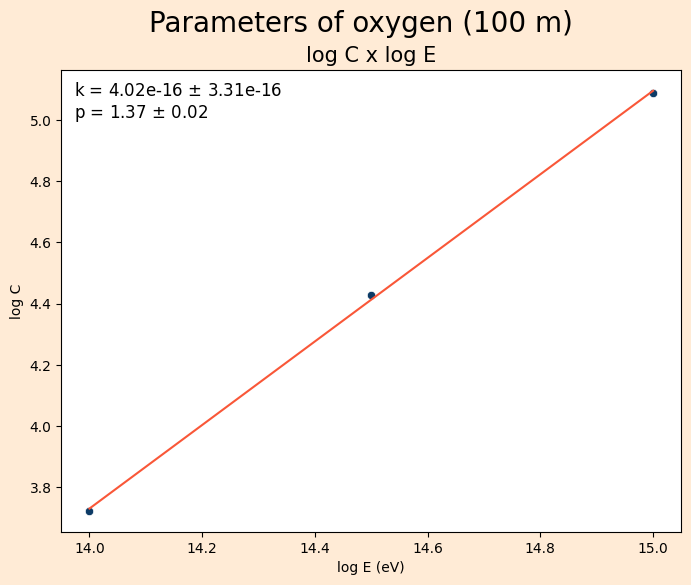

In [95]:
# Fit do oxigênio
from scipy.optimize import curve_fit

C = [5281, 2.671e+04, 1.227e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of oxygen (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_oxygen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_oxygen))

ax.plot(logE, power(E,*coefficients_oxygen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_oxygen[0],inc[0],coefficients_oxygen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_oxygen[0]))/coefficients_oxygen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[2.35395954e-15 3.98679384e-02]
[4.06730312 4.73902106 5.4115803 ]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_36376\3778982861.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_36376\3778982861.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.078819,14.0,14.008567,0.061191
4.716003,14.499687,14.482564,0.11809
5.423082,15.0,15.008556,0.05704


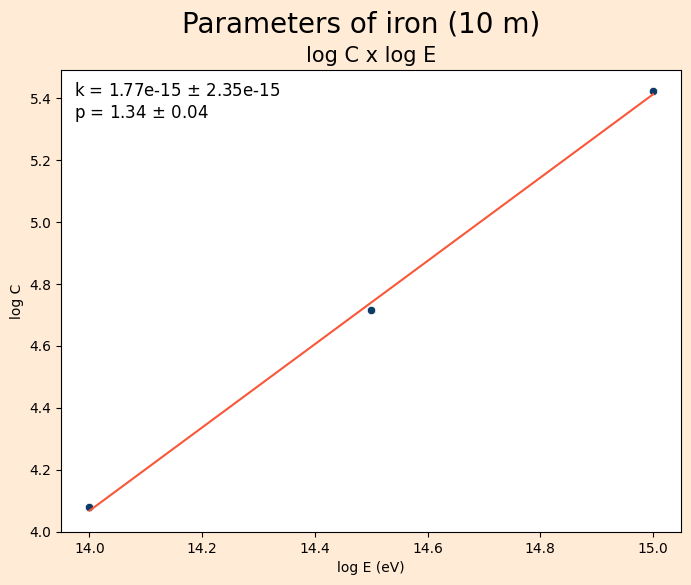

In [96]:
# Fit do ferro
from scipy.optimize import curve_fit

C = [1.199e+04, 5.2e+04, 2.649e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_iron, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_iron))

ax.plot(logE, power(E,*coefficients_iron), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_iron[0],inc[0],coefficients_iron[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_iron[0]))/coefficients_iron[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [97]:
# Reconstrução da energia

E_real = [1E14, 3.16E14, 1E15]
r0 = 7800

# Parâmetros fóton

k_photon = coefficients_photon[0] 
p_photon = coefficients_photon[1] 
c_photon = [476.7,2411,1.293e+04] 
E_photon = []


for i in range(len(c_photon)):
    E = (c_photon[i]/k_photon)**(1/p_photon)
    E_photon.append(E)


# Parâmetros próton

k_proton = coefficients_proton[0]
p_proton = coefficients_proton[1]
c_proton = [566.7,2740,1.248e+04]
E_proton = []

for i in range(len(c_photon)):
    E = (c_proton[i]/k_proton)**(1/p_proton)
    E_proton.append(E)

# Parâmetros carbono

k_carbon = coefficients_carbon[0]
p_carbon = coefficients_carbon[1]
c_carbon = [158.1,861,6107]
E_carbon = []

for i in range(len(c_photon)):
    E = (c_carbon[i]/k_carbon)**(1/p_carbon)
    E_carbon.append(E)

# Parâmetros nitrogênio

k_nitrogen = coefficients_nitrogen[0]
p_nitrogen = coefficients_nitrogen[1]
c_nitrogen = [130.5,939.6,4829]
E_nitrogen = []

for i in range(len(c_photon)):
    E = (c_nitrogen[i]/k_nitrogen)**(1/p_nitrogen)
    E_nitrogen.append(E)

# Parâmetros oxigênio

k_oxygen = coefficients_oxygen[0]
p_oxygen = coefficients_oxygen[1]
c_oxygen = [132.3,775.1,5115]
E_oxygen = []

for i in range(len(c_photon)):
    E = (c_oxygen[i]/k_oxygen)**(1/p_oxygen)
    E_oxygen.append(E)

# Parâmetros ferro

k_iron = coefficients_iron[0]
p_iron = coefficients_iron[1]
c_iron = [36.59,294.4,2545]
E_iron = []

for i in range(len(c_iron)):
    E = (c_iron[i]/k_iron)**(1/p_iron)
    E_iron.append(E)
    


data = {
    'E':E_real,
    'E_photon':E_photon,
    'E_proton':E_proton,
    'E_carbon':E_carbon,
    'E_nitrogen':E_nitrogen,
    'E_oxygen':E_oxygen,
    'E_iron':E_iron
}

df = pl.DataFrame(data)
df

E,E_photon,E_proton,E_carbon,E_nitrogen,E_oxygen,E_iron
f64,f64,f64,f64,f64,f64,f64
1.0000e14,5.3050e12,2.6581e12,2.1065e11,7.0306e12,6.6489e12,1.3719e12
3.1600e14,1.7443e13,1.0043e13,1.8771e12,2.9232e13,2.4254e13,6.4712e12
1.0000e15,5.9873e13,3.6083e13,2.3525e13,9.5288e13,9.6525e13,3.2198e13


[Text(0.5, 1.0, 'Energy relative diviation $\\Delta$E/E')]

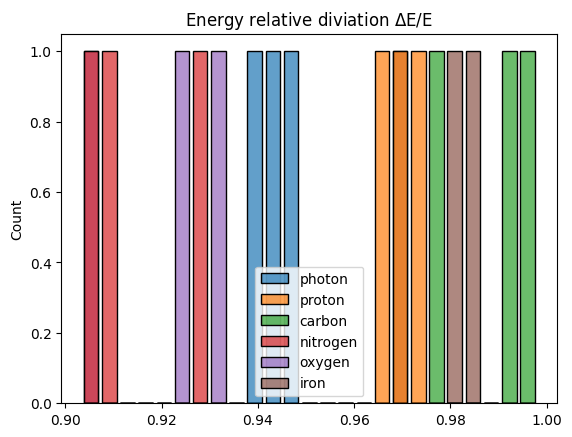

In [98]:
DeltaE_photon = []
DeltaE_proton = []
DeltaE_carbon = []
DeltaE_nitrogen = []
DeltaE_oxygen = []
DeltaE_iron = []

for i in range(len(E_real)):
    aux = (E_real[i] - E_photon[i])/E_real[i]
    aux2 = (E_real[i] - E_proton[i])/E_real[i]
    aux3 = (E_real[i] - E_carbon[i])/E_real[i]
    aux4 = (E_real[i] - E_nitrogen[i])/E_real[i]
    aux5 = (E_real[i] - E_oxygen[i])/E_real[i]
    aux6 = (E_real[i] - E_iron[i])/E_real[i]
    DeltaE_photon.append(aux)
    DeltaE_proton.append(aux2)
    DeltaE_carbon.append(aux3)
    DeltaE_nitrogen.append(aux4)
    DeltaE_oxygen.append(aux5)
    DeltaE_iron.append(aux6)

data = {
    'photon':DeltaE_photon,
    'proton':DeltaE_proton,
    'carbon':DeltaE_carbon,
    'nitrogen':DeltaE_nitrogen,
    'oxygen':DeltaE_oxygen,
    'iron':DeltaE_iron
}

sns.histplot(data=data, bins= 25, shrink=0.8, alpha = 0.7).set(title = 'Energy relative diviation $\Delta$E/E')